In [41]:
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np

import os
import sys

import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
from plotnine import *
from tqdm import tqdm

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import logging


logging.basicConfig(format="[%(asctime)s] %(levelname)s:%(name)s: %(message)s", stream=sys.stdout)
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)


def get_efficiancy(adata, target_column = "perturbed_gene_name", no_target_key = "NTC"):
    all_targets = adata.var_names[adata.var_names.isin(adata.obs[target_column].unique())]
    results = {}
    adata_control = adata[adata.obs[target_column] == no_target_key]
    control_means = np.array(adata_control.X.mean(0)).flatten()

    for gene in tqdm(all_targets):
        adata_target = adata[adata.obs[target_column] == gene, gene]
        pert_mean = adata_target.X.mean()
        control_mean = control_means[np.argwhere(adata.var_names==gene)[0]]
        
        results[gene] = {
            'control_mean': control_mean,
            'perturbed_mean': pert_mean,
            'fraction': pert_mean / control_mean
        }

    df_results = pd.DataFrame(results).T
    df_results = df_results.reset_index()
    df_results.columns = ['gene', 'control_mean', 'perturbed_mean', 'fraction']

    df_results["fraction"] = df_results["fraction"].astype("float")
    df_results["control_mean"] = df_results["control_mean"].astype("float")

    
    return df_results



---
## Load and evaluate target efficiencies for different datasets

In [42]:

if not os.path.exists("/g/stegle/schrod/code/TCell/knockdowns/otar.csv"):
    logger.info(f"Load adata...")
    adata_path = "/g/stegle/schrod/data/T_Cell/promoter_single_guide_hvg.h5ad"
    adata = ad.read_h5ad(os.path.join(adata_path))
    df_otar = get_efficiancy(adata, target_column = "target", no_target_key = "NO-TARGET")
    df_otar.to_csv("/g/stegle/schrod/code/TCell/knockdowns/otar.csv")
else:
    logger.info("Loading existing OTAR data...")
    df_otar = pd.read_csv("/g/stegle/schrod/code/TCell/knockdowns/otar.csv", index_col=0)
df_otar['origin'] = 'OTAR'


[2026-02-20 13:28:25,201] INFO:__main__: Loading existing OTAR data...


In [43]:
if not os.path.exists("/g/stegle/schrod/code/TCell/knockdowns/ipsc_fitness.csv"):
    fitness_adata = sc.read_h5ad("/g/stegle/schrod/data/ipsc/GenomeWideScreen_FitnessGenes_RNA-UMI-Counts.h5ad")
    fitness_adata.var_names = fitness_adata.var["gene_name"]
    sc.pp.normalize_total(fitness_adata, target_sum=5000)
    sc.pp.log1p(fitness_adata)
    df_fitness = get_efficiancy(fitness_adata, target_column = "target", no_target_key="unassigned")
    df_fitness.to_csv("/g/stegle/schrod/code/TCell/knockdowns/ipsc_fitness.csv")
else:
    logger.info("Loading existing iPSC Fitness data...")
    df_fitness = pd.read_csv("/g/stegle/schrod/code/TCell/knockdowns/ipsc_fitness.csv", index_col=0)
df_fitness['origin'] = 'iPSC Fitness'
        
if not os.path.exists("/g/stegle/schrod/code/TCell/knockdowns/ipsc_nonfitness.csv"):
    nonfitness_adata = sc.read_h5ad("/g/stegle/schrod/data/ipsc/GenomeWideScreen_NonFitnessGenes_RNA-UMI-Counts.h5ad")
    nonfitness_adata.var_names = nonfitness_adata.var["gene_name"]
    sc.pp.normalize_total(nonfitness_adata, target_sum=5000)
    sc.pp.log1p(nonfitness_adata)
    df_nonfitness = get_efficiancy(nonfitness_adata, target_column = "target", no_target_key="unassigned")
    df_nonfitness.to_csv("/g/stegle/schrod/code/TCell/knockdowns/ipsc_nonfitness.csv")
else:
    logger.info("Loading existing iPSC NonFitness data...")
    df_nonfitness = pd.read_csv("/g/stegle/schrod/code/TCell/knockdowns/ipsc_nonfitness.csv", index_col=0)
df_nonfitness['origin'] = 'iPSC NonFitness'

[2026-02-20 13:28:25,482] INFO:__main__: Loading existing iPSC Fitness data...
[2026-02-20 13:28:25,527] INFO:__main__: Loading existing iPSC NonFitness data...


In [44]:
if not os.path.exists("/g/stegle/schrod/code/TCell/knockdowns/K562_gwps.csv"):
    rep_K562_gwps_path = '/g/stegle/schrod/data/replogle/K562_gwps_raw_singlecell_01.h5ad'
    K562_gwps = ad.read_h5ad(os.path.join(rep_K562_gwps_path))
    K562_gwps.obs["target"]=K562_gwps.obs["gene"]
    K562_gwps.var_names = K562_gwps.var["gene_name"]
    sc.pp.normalize_total(K562_gwps)
    sc.pp.log1p(K562_gwps)

    df_K562_gwps = get_efficiancy(K562_gwps, target_column = "target", no_target_key="non-targeting")
    df_K562_gwps.to_csv("/g/stegle/schrod/code/TCell/knockdowns/K562_gwps.csv")
else:
    logger.info("Loading existing K562 GWPS data...")
    df_K562_gwps = pd.read_csv("/g/stegle/schrod/code/TCell/knockdowns/K562_gwps.csv", index_col=0)
df_K562_gwps['origin'] = 'K562 GWPS'


[2026-02-20 13:28:25,798] INFO:__main__: Loading existing K562 GWPS data...


In [45]:
if not os.path.exists("/g/stegle/schrod/code/TCell/knockdowns/Marson.csv"):
    print("Reading and processing Marson D1-D4 data...")
    adataD1 = sc.read_h5ad("/scratch/schrod/data/marson/D1_Stim48hr.assigned_guide.h5ad")
    adataD2 = sc.read_h5ad("/scratch/schrod/data/marson/D2_Stim48hr.assigned_guide.h5ad")
    adataD3 = sc.read_h5ad("/scratch/schrod/data/marson/D3_Stim48hr.assigned_guide.h5ad")
    adataD4 = sc.read_h5ad("/scratch/schrod/data/marson/D4_Stim48hr.assigned_guide.h5ad")
    
    # Only keep genes which appear as target
    adataD1 = adataD1[adataD1.obs.guide_group == "targeting single sgRNA"]
    adataD2 = adataD2[adataD2.obs.guide_group == "targeting single sgRNA"]
    adataD3 = adataD3[adataD3.obs.guide_group == "targeting single sgRNA"]
    adataD4 = adataD4[adataD4.obs.guide_group == "targeting single sgRNA"]
    
    # Combine target groups
    t1 = adataD1.obs.perturbed_gene_name.unique()
    t2 = adataD2.obs.perturbed_gene_name.unique()
    t3 = adataD3.obs.perturbed_gene_name.unique()
    t4 = adataD4.obs.perturbed_gene_name.unique()
    all_targets = np.unique(np.concatenate([t1, t2, t3, t4]))
    
    # Filter to target genes
    adataD1 = adataD1[:,adataD1.var.gene_name.isin(all_targets)]
    adataD2 = adataD2[:,adataD2.var.gene_name.isin(all_targets)]
    adataD3 = adataD3[:,adataD3.var.gene_name.isin(all_targets)]
    adataD4 = adataD4[:,adataD4.var.gene_name.isin(all_targets)]
    
    # Set var_names
    adataD1.var_names = adataD1.var.gene_name
    adataD2.var_names = adataD2.var.gene_name
    adataD3.var_names = adataD3.var.gene_name
    adataD4.var_names = adataD4.var.gene_name
    
    # Concatenate
    adata_marson = ad.concat([adataD1, adataD2, adataD3, adataD4], label="donor", keys=["D1", "D2", "D3", "D4"])
    
    # Normalize
    sc.pp.normalize_total(adata_marson)
    sc.pp.log1p(adata_marson)
    
    # Compute efficiency
    df_marson = get_efficiancy(adata_marson, target_column="perturbed_gene_name", no_target_key="NTC")
    df_marson.to_csv("/g/stegle/schrod/code/TCell/knockdowns/Marson.csv")
else:
    logger.info("Loading existing Marson D1-D4 data...")
    df_marson = pd.read_csv("/g/stegle/schrod/code/TCell/knockdowns/Marson.csv", index_col=0)
df_marson['origin'] = 'Marson'



[2026-02-20 13:28:26,133] INFO:__main__: Loading existing Marson D1-D4 data...


In [46]:
if not os.path.exists("/g/stegle/schrod/code/TCell/knockdowns/K562.csv"):
    rep_K562_essential_path = '/g/stegle/schrod/data/replogle/K562_essential_raw_singlecell_01.h5ad'
    K562 = ad.read_h5ad(os.path.join(rep_K562_essential_path))
    K562.obs["target"]=K562.obs["gene"]
    K562.var_names = K562.var["gene_name"]
    sc.pp.normalize_total(K562)
    sc.pp.log1p(K562)

    df_K562 = get_efficiancy(K562, target_column = "target", no_target_key="non-targeting")
    df_K562.to_csv("/g/stegle/schrod/code/TCell/knockdowns/K562.csv")
else:
    logger.info("Loading existing K562 data...")
    df_K562 = pd.read_csv("/g/stegle/schrod/code/TCell/knockdowns/K562.csv", index_col=0)
df_K562['origin'] = 'K562'


[2026-02-20 13:28:26,545] INFO:__main__: Loading existing K562 data...


In [47]:
if not os.path.exists("/g/stegle/schrod/code/TCell/knockdowns/rpe1.csv"):
    rep_rpe1_essential_path = '/g/stegle/schrod/data/replogle/rpe1_raw_singlecell_01.h5ad'
    rpe1 = ad.read_h5ad(os.path.join(rep_rpe1_essential_path))
    rpe1.obs["target"]=rpe1.obs["gene"]
    rpe1.var_names = rpe1.var["gene_name"]
    sc.pp.normalize_total(rpe1)
    sc.pp.log1p(rpe1)

    df_rpe1 = get_efficiancy(rpe1, target_column = "target", no_target_key="non-targeting")
    df_rpe1.to_csv("/g/stegle/schrod/code/TCell/knockdowns/rpe1.csv")
else:
    logger.info("Loading existing RPE1 data...")
    df_rpe1 = pd.read_csv("/g/stegle/schrod/code/TCell/knockdowns/rpe1.csv", index_col=0)
df_rpe1['origin'] = 'RPE1'



[2026-02-20 13:28:27,175] INFO:__main__: Loading existing RPE1 data...


---
## Plot Results

[2026-02-16 14:22:47,973] INFO:__main__: Creating combined knockdown efficiency plot...
[2026-02-16 14:22:47,984] INFO:__main__: Added OTAR: 7632 genes, 69.6% effective (≤50% remaining)
[2026-02-16 14:22:47,985] INFO:__main__: Added K562: 1868 genes, 88.5% effective (≤50% remaining)
[2026-02-16 14:22:47,986] INFO:__main__: Added K562 GWPS: 7684 genes, 85.6% effective (≤50% remaining)
[2026-02-16 14:22:47,987] INFO:__main__: Added RPE1: 2107 genes, 93.8% effective (≤50% remaining)
[2026-02-16 14:22:47,988] INFO:__main__: Added iPSC Fitness: 2199 genes, 16.8% effective (≤50% remaining)
[2026-02-16 14:22:47,989] INFO:__main__: Added iPSC NonFitness: 4950 genes, 6.6% effective (≤50% remaining)
[2026-02-16 14:22:47,990] INFO:__main__: Added Marson: 11801 genes, 78.6% effective (≤50% remaining)


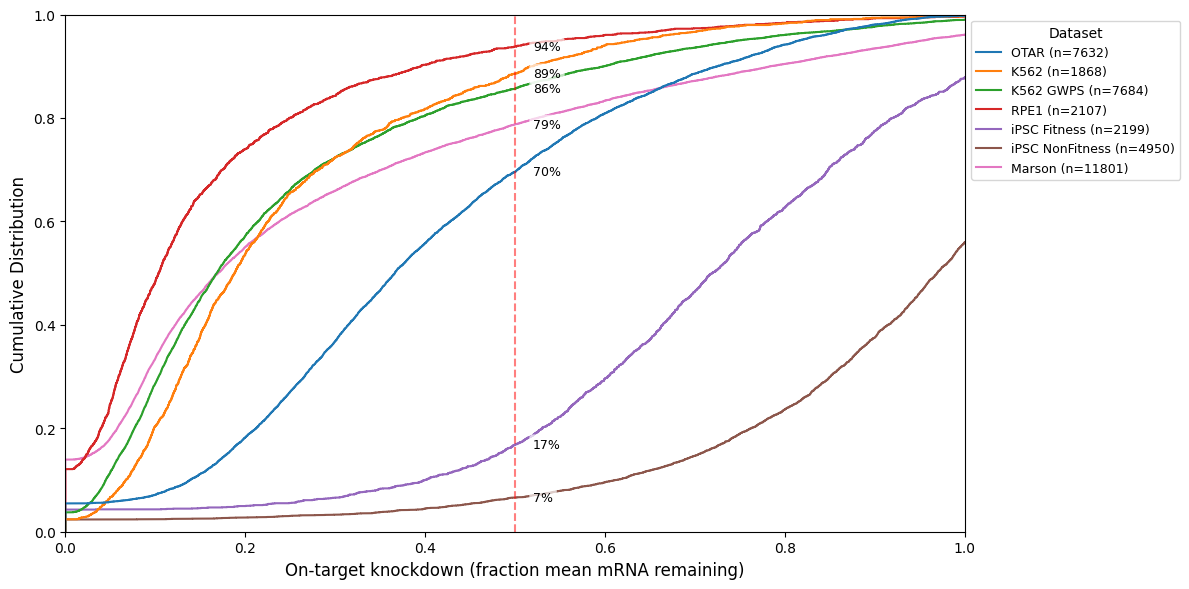

[2026-02-16 14:22:48,956] INFO:__main__: Plot saved successfully


In [8]:
# Create combined plot with all available datasets
logger.info("Creating combined knockdown efficiency plot...")

# Collect all available datasets
plot_df_list = []
dataset_info = []  # Store dataset info for labels
for df, name in [(df_otar, 'OTAR'), (df_K562, 'K562'), (df_K562_gwps, 'K562 GWPS'), 
                  (df_rpe1, 'RPE1'), (df_fitness, 'iPSC Fitness'), 
                  (df_nonfitness, 'iPSC NonFitness'), (df_marson, 'Marson')]:
    if df is not None:
        # Calculate efficiency (percentage with fraction <= 0.5)
        pct_effective = (df['fraction'] <= 0.5).sum() / len(df) * 100
        median_frac = df['fraction'].median()
        
        df_copy = df[['fraction', 'origin']].copy()
        # Keep simple origin name for legend
        df_copy['origin'] = f"{name} (n={len(df)})"
        plot_df_list.append(df_copy)
        dataset_info.append({'name': name, 'label': f"{name} (n={len(df)})", 
                            'pct_effective': pct_effective, 'median': median_frac})
        logger.info(f"Added {name}: {len(df)} genes, {pct_effective:.1f}% effective (≤50% remaining)")

if plot_df_list:
    df_combined = pd.concat(plot_df_list).reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.ecdfplot(data=df_combined, x="fraction", hue="origin", ax=ax)
    
    # Add text annotations for each dataset showing efficiency
    # Position text at x=0.6 and get corresponding y-value from ECDF
    for info in dataset_info:
        dataset_label = info['label']
        pct = info['pct_effective']
        
        # Get the corresponding ECDF line for this dataset
        dataset_df = df_combined[df_combined['origin'] == dataset_label]
        # Calculate ECDF value at x=0.6
        ecdf_val = (dataset_df['fraction'] <= 0.5).sum() / len(dataset_df)
        
        # Add text annotation
        ax.text(0.52, ecdf_val, f"{pct:.0f}%", 
               fontsize=9, ha='left', va='center',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))
    
    ax.set_xlim(0, 1)
    ax.set_xlabel("On-target knockdown (fraction mean mRNA remaining)", fontsize=12)
    ax.set_ylabel("Cumulative Distribution", fontsize=12)
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title="Dataset", fontsize=9)
    plt.tight_layout()
    plt.savefig("/g/stegle/schrod/code/TCell/plots/final/All_datasets_knockdown_comparison.pdf", bbox_inches='tight')
    plt.show()
    logger.info("Plot saved successfully")
else:
    logger.warning("No datasets available for plotting")







---
# Knockdown efficiency per target

In [48]:
def load_deg_results(file_path, pval_threshold = None):
    df_list = []
    for file_name in tqdm(os.listdir(file_path)):
        df_tmp = pd.read_csv(os.path.join(file_path, file_name))
        if pval_threshold is not None:
            df_tmp = df_tmp[df_tmp["pvals_adj"] < pval_threshold]
        df_list.append(df_tmp)
    df1 = pd.concat(df_list)
    return df1

deg_res = load_deg_results("/g/stegle/schrod/code/TCell/pseudobulk_deseq2_chunks50_min3bulks_ribosomal")
deg_res
deg_res = deg_res.rename(columns = {'contrast': 'KO', 'variable': 'gene_name',
                                'log_fc': 'LFC', 'adj_p_value': 'adj_pval'})

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 146/146 [00:54<00:00,  2.68it/s]


In [18]:
mask = deg_res.adj_pval.isna()
deg_res[mask].KO.unique().shape
deg_res[mask].KO.value_counts()
mask.sum()/deg_res.shape[0]

np.float64(0.026276064806967623)

In [50]:
deg_sig = deg_res[deg_res.adj_pval<0.1]
on_target = deg_sig[deg_sig.KO == deg_sig.gene_name].gene_name.unique()

In [4]:
### Save Table S12
deg_sig = deg_sig.iloc[:,1:]
# move KO to first column
cols = deg_sig.columns.tolist()
cols.insert(0, cols.pop(cols.index('KO')))
deg_sig = deg_sig[cols]
deg_sig.to_excel("/g/stegle/schrod/code/TCell/Table S12.xlsx", index=False)

In [5]:
(deg_sig.KO == deg_sig.gene_name).sum()

np.int64(4311)

KO
EIF5A        1656
RACK1        1549
DBR1         1344
IL2RG        1268
TAF3         1211
             ... 
NINJ1           1
NIPA2           1
NIPSNAP2        1
NIPSNAP3A       1
PGRMC1          1
Name: count, Length: 5888, dtype: int64

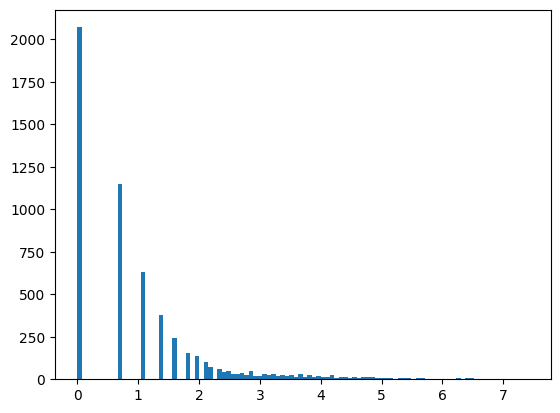

In [7]:
plt.hist(np.log(deg_sig.KO.value_counts()), bins=100)
deg_sig.KO.value_counts()

gene_name
MDM2      147
RPS19     131
RPS27L    124
TPT1      121
HSPA1B    118
         ... 
TNXB        1
ZNF671      1
CAPN10      1
PRPF18      1
CCL3L1      1
Name: count, Length: 7618, dtype: int64

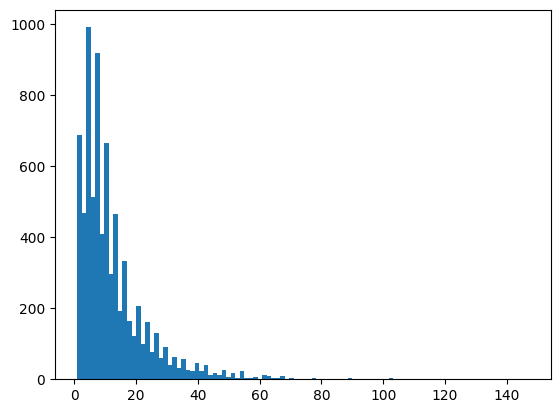

In [8]:
plt.hist(deg_sig.gene_name.value_counts(), bins=100)
deg_sig.gene_name.value_counts()

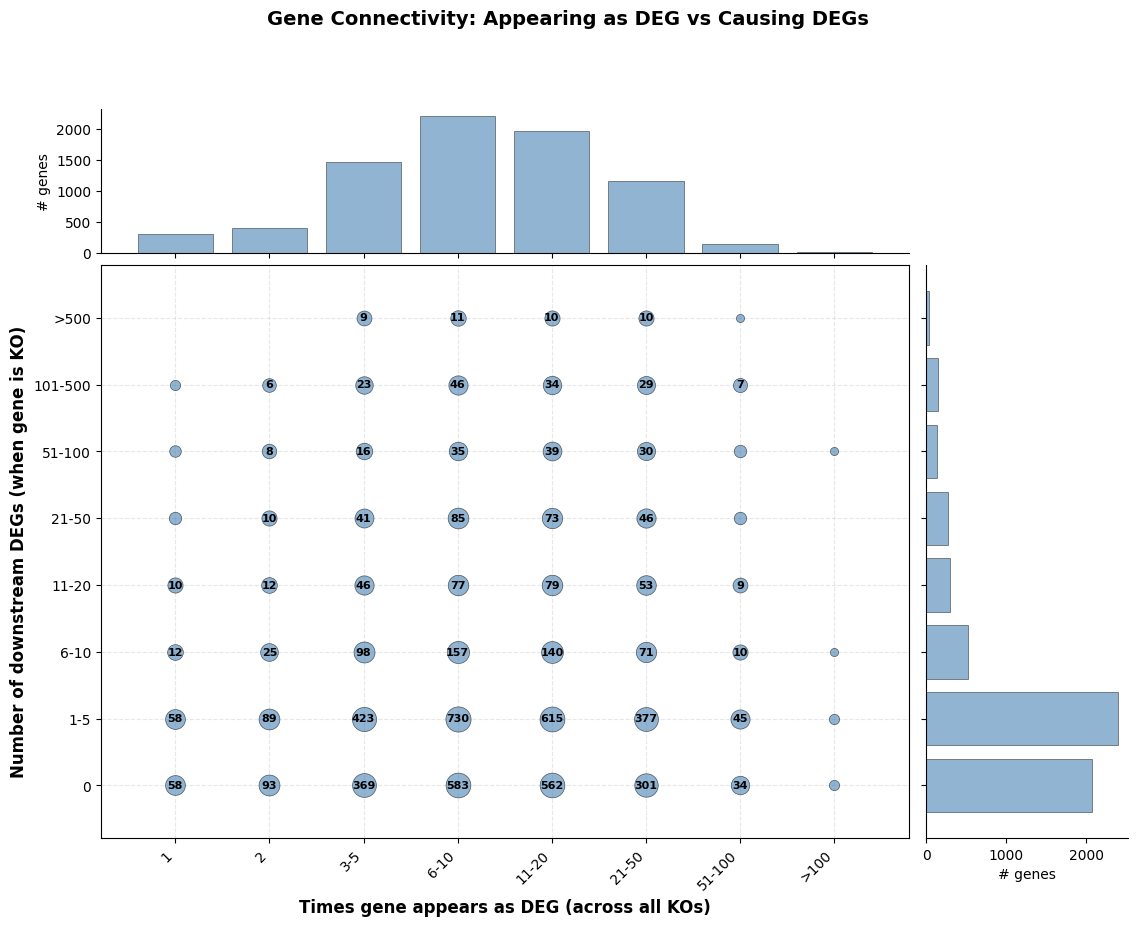

[2026-02-20 13:29:57,821] INFO:__main__: Total genes in analysis: 7778
[2026-02-20 13:29:57,822] INFO:__main__: Genes appearing as DEGs: 7618
[2026-02-20 13:29:57,823] INFO:__main__: Genes with downstream DEGs: 5888
[2026-02-20 13:29:57,824] INFO:__main__: Genes in both categories: 5728


In [51]:
# Create dotplot showing relationship between gene appearance as DEG and downstream effects
# X-axis: How many times a gene appears as a DEG (across all KOs)
# Y-axis: How many DEGs that gene has when it's knocked out

# Count appearances as DEG
gene_as_deg_counts = deg_sig.gene_name.value_counts().reset_index()
gene_as_deg_counts.columns = ['gene', 'appears_as_deg']

# Count DEGs per KO
ko_deg_counts = deg_sig.KO.value_counts().reset_index()
ko_deg_counts.columns = ['gene', 'n_downstream_degs']

# Merge to get genes that appear in both dimensions
dotplot_df = gene_as_deg_counts.merge(ko_deg_counts, on='gene', how='outer').fillna(0)
dotplot_df['appears_as_deg'] = dotplot_df['appears_as_deg'].astype(int)
dotplot_df['n_downstream_degs'] = dotplot_df['n_downstream_degs'].astype(int)

# Create bins for aggregation to make the dotplot clearer
dotplot_df['appears_as_deg_bin'] = pd.cut(dotplot_df['appears_as_deg'], 
                                            bins=[0, 1, 2, 5, 10, 20, 50, 100, np.inf],
                                            labels=['1', '2', '3-5', '6-10', '11-20', '21-50', '51-100', '>100'])
dotplot_df['n_downstream_degs_bin'] = pd.cut(dotplot_df['n_downstream_degs'], 
                                               bins=[0, 1, 5, 10, 20, 50, 100, 500, np.inf],
                                               labels=['0', '1-5', '6-10', '11-20', '21-50', '51-100', '101-500', '>500'])

# Count genes in each bin combination
heatmap_data = dotplot_df.groupby(['n_downstream_degs_bin', 'appears_as_deg_bin']).size().reset_index(name='count')

# Pivot for heatmap
heatmap_pivot = heatmap_data.pivot(index='n_downstream_degs_bin', columns='appears_as_deg_bin', values='count').fillna(0)

# Create figure with marginal histograms
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(14, 10))
gs = GridSpec(3, 3, figure=fig, height_ratios=[1, 4, 0.2], width_ratios=[0.2, 4, 1], 
              hspace=0.05, wspace=0.05)

# Main dotplot
ax_main = fig.add_subplot(gs[1, 1])

# Create scatter plot with size proportional to count
for i, y_cat in enumerate(heatmap_pivot.index):
    for j, x_cat in enumerate(heatmap_pivot.columns):
        count = heatmap_pivot.loc[y_cat, x_cat]
        if count > 0:
            # Size proportional to log(count) for better visualization
            size = np.log1p(count) * 50
            ax_main.scatter(j, i, s=size, alpha=0.6, c='steelblue', edgecolors='black', linewidth=0.5)
            # Add count label if substantial
            if count >= 5:
                ax_main.text(j, i, f'{int(count)}', ha='center', va='center', fontsize=8, fontweight='bold')

ax_main.set_xticks(range(len(heatmap_pivot.columns)))
ax_main.set_xticklabels(heatmap_pivot.columns, rotation=45, ha='right')
ax_main.set_yticks(range(len(heatmap_pivot.index)))
ax_main.set_yticklabels(heatmap_pivot.index)

ax_main.set_xlabel('Times gene appears as DEG (across all KOs)', fontsize=12, fontweight='bold')
ax_main.set_ylabel('Number of downstream DEGs (when gene is KO)', fontsize=12, fontweight='bold')

# Add grid for clarity
ax_main.grid(True, alpha=0.3, linestyle='--')
ax_main.set_axisbelow(True)

# Top histogram (x-axis distribution)
ax_top = fig.add_subplot(gs[0, 1], sharex=ax_main)
# Count genes per bin for x-axis
x_counts = dotplot_df.groupby('appears_as_deg_bin').size()
x_positions = range(len(heatmap_pivot.columns))
ax_top.bar(x_positions, [x_counts.get(cat, 0) for cat in heatmap_pivot.columns], 
           color='steelblue', alpha=0.6, edgecolor='black', linewidth=0.5)
ax_top.set_ylabel('# genes', fontsize=10)
ax_top.tick_params(labelbottom=False)
ax_top.spines['top'].set_visible(False)
ax_top.spines['right'].set_visible(False)

# Right histogram (y-axis distribution)
ax_right = fig.add_subplot(gs[1, 2], sharey=ax_main)
# Count genes per bin for y-axis
y_counts = dotplot_df.groupby('n_downstream_degs_bin').size()
y_positions = range(len(heatmap_pivot.index))
ax_right.barh(y_positions, [y_counts.get(cat, 0) for cat in heatmap_pivot.index], 
              color='steelblue', alpha=0.6, edgecolor='black', linewidth=0.5)
ax_right.set_xlabel('# genes', fontsize=10)
ax_right.tick_params(labelleft=False)
ax_right.spines['top'].set_visible(False)
ax_right.spines['right'].set_visible(False)

# Add title to the figure
fig.suptitle('Gene Connectivity: Appearing as DEG vs Causing DEGs', fontsize=14, fontweight='bold', y=0.98)

plt.savefig('/g/stegle/schrod/code/TCell/plots/final/gene_connectivity_dotplot.pdf', bbox_inches='tight')
plt.show()

# Also show summary statistics
logger.info(f"Total genes in analysis: {len(dotplot_df)}")
logger.info(f"Genes appearing as DEGs: {(dotplot_df['appears_as_deg'] > 0).sum()}")
logger.info(f"Genes with downstream DEGs: {(dotplot_df['n_downstream_degs'] > 0).sum()}")
logger.info(f"Genes in both categories: {((dotplot_df['appears_as_deg'] > 0) & (dotplot_df['n_downstream_degs'] > 0)).sum()}")



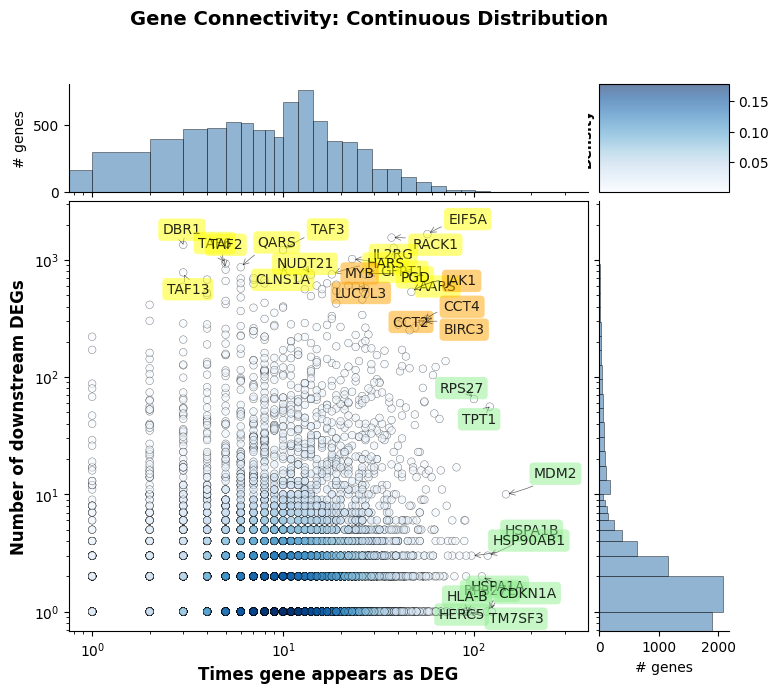

[2026-02-20 13:42:15,069] INFO:__main__: 
Connectivity Statistics:
[2026-02-20 13:42:15,071] INFO:__main__: Correlation between appearance as DEG and causing DEGs: 0.046
[2026-02-20 13:42:15,072] INFO:__main__: Genes causing more DEGs than they appear in: 1243
[2026-02-20 13:42:15,072] INFO:__main__: Genes appearing in more DEGs than they cause: 6341
[2026-02-20 13:42:15,073] INFO:__main__: 
Highly connected genes (>20 in both dimensions): 132
[2026-02-20 13:42:15,074] INFO:__main__: Examples: AARS, ABCE1, ANKH, ARF1, ARG2, ARPC5L, BCL3, BIRC3, BTF3, CAMK4


In [64]:
# Alternative visualization: Scatter plot with log scales and density coloring
# Better for seeing the continuous distribution and outliers

from matplotlib.gridspec import GridSpec
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["svg.fonttype"] = 'none'

# Create figure with marginal histograms
fig = plt.figure(figsize=(6*1.5, 5*1.5))
gs = GridSpec(3, 3, figure=fig, height_ratios=[1, 4, 0.2], width_ratios=[0.2, 4, 1], 
              hspace=0.05, wspace=0.05)

# Main scatter plot
ax = fig.add_subplot(gs[1, 1])

# Use values directly (no pseudocount needed for symlog)
x_vals = dotplot_df['appears_as_deg']
y_vals = dotplot_df['n_downstream_degs']

# Create scatter plot with color based on density
from scipy.stats import gaussian_kde

# Calculate point density for coloring (use asinh transformation for density calculation)
xy = np.vstack([np.arcsinh(x_vals), np.arcsinh(y_vals)])
z = gaussian_kde(xy)(xy)

# Create scatter plot
scatter = ax.scatter(x_vals, y_vals, c=z, s=30, alpha=0.6, cmap='Blues', 
                     edgecolors='black', linewidths=0.3)

# Set symlog scales (pseudolog)
ax.set_xscale('symlog', linthresh=10)
#ax.set_xscale('log')
ax.set_yscale('symlog', linthresh=10)
#ax.set_yscale('log')

# Add colorbar in top right corner
cb = plt.colorbar(scatter, ax=ax, cax=fig.add_subplot(gs[0, 2]))
cb.set_label('Density', fontsize=10, fontweight='bold')
cb.ax.yaxis.set_label_position('left')

# Add diagonal line (genes that appear as DEG = genes they affect)
max_val = max(x_vals.max(), y_vals.max())
# Annotate interesting outliers with varied positioning to avoid overlap
annotated_genes = set()
annotations = []

# Define offset patterns to distribute annotations and reduce overlap
offset_patterns = [
    (15, 8), (15, -8), (-15, 8), (-15, -8),
    (20, 12), (20, -12), (-20, 12), (-20, -12),
    (12, 15), (-12, 15), (12, -15), (-12, -15),
    (25, 5), (25, -5), (-25, 5), (-25, -5)
]

# 1. Top genes with high downstream effects (upstream regulators - yellow)
top_causers = dotplot_df.nlargest(15, 'n_downstream_degs')
for i, (idx, row) in enumerate(top_causers.iterrows()):
    if row['n_downstream_degs'] > 15 and row['gene'] not in annotated_genes:
        offset = offset_patterns[i % len(offset_patterns)]
        ax.annotate(row['gene'], 
                   xy=(row['appears_as_deg'], row['n_downstream_degs']),
                   xytext=offset, textcoords='offset points',
                   fontsize=10, alpha=0.85,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5, edgecolor='none'),
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', alpha=0.6, lw=0.5))
        annotated_genes.add(row['gene'])

# 2. Genes that appear frequently as DEGs (downstream targets - green)
top_targets = dotplot_df.nlargest(15, 'appears_as_deg')
for i, (idx, row) in enumerate(top_targets.iterrows()):
    if row['appears_as_deg'] > 15 and row['gene'] not in annotated_genes:
        offset = offset_patterns[(i + 4) % len(offset_patterns)]  # Offset pattern start
        ax.annotate(row['gene'], 
                   xy=(row['appears_as_deg'], row['n_downstream_degs']),
                   xytext=offset, textcoords='offset points',
                   fontsize=10, alpha=0.85,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.5, edgecolor='none'),
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.1', alpha=0.6, lw=0.5))
        annotated_genes.add(row['gene'])

# 3. Highly connected hub genes (high in both dimensions - orange)
dotplot_df['connectivity_score'] = dotplot_df['appears_as_deg'] * dotplot_df['n_downstream_degs']
hub_genes = dotplot_df.nlargest(12, 'connectivity_score')
for i, (idx, row) in enumerate(hub_genes.iterrows()):
    if row['appears_as_deg'] > 10 and row['n_downstream_degs'] > 10 and row['gene'] not in annotated_genes:
        offset = offset_patterns[(i + 8) % len(offset_patterns)]
        ax.annotate(row['gene'], 
                   xy=(row['appears_as_deg'], row['n_downstream_degs']),
                   xytext=offset, textcoords='offset points',
                   fontsize=10, alpha=0.85,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='orange', alpha=0.5, edgecolor='none'),
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', alpha=0.6, lw=0.5))
        annotated_genes.add(row['gene'])

# Add custom legend for gene annotations
from matplotlib.patches import Rectangle
legend_elements = [
    Rectangle((0, 0), 1, 1, fc='yellow', alpha=0.5, edgecolor='none', label='Top downstream regulators (>15 DEGs)'),
    Rectangle((0, 0), 1, 1, fc='lightgreen', alpha=0.5, edgecolor='none', label='Most regulated (>15 KOs)'),
    Rectangle((0, 0), 1, 1, fc='orange', alpha=0.5, edgecolor='none', label='Hub genes (>10 both dimensions)')
]
#annotation_legend = ax.legend(handles=legend_elements, loc='upper left', 
#                             fontsize=8, framealpha=0.9, title='Gene Categories', title_fontsize=9)

ax.set_xlabel('Times gene appears as DEG', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of downstream DEGs', fontsize=12, fontweight='bold')

# Custom formatter to show integers for symlog scale
from matplotlib.ticker import FuncFormatter
def format_func(value, tick_number):
    return f'{int(value)}'

ax.xaxis.set_major_formatter(FuncFormatter(format_func))
ax.yaxis.set_major_formatter(FuncFormatter(format_func))

#ax.grid(True, alpha=0.3, linestyle='--', which='both')
ax.grid(False)

# Top histogram (x-axis distribution) with symlog scale
ax_top = fig.add_subplot(gs[0, 1], sharex=ax)
# Use appropriate bins for symlog scale
bins_x = np.concatenate([np.linspace(0, 10, 11), np.logspace(np.log10(10), np.log10(x_vals.max()+150), 20)])
ax_top.hist(x_vals, bins=bins_x, color='steelblue', alpha=0.6, edgecolor='black', linewidth=0.5)
#ax_top.set_xscale('symlog', linthresh=10)
ax_top.set_xscale('log')
ax_top.set_ylabel('# genes', fontsize=10)
ax_top.tick_params(labelbottom=False)
ax_top.spines['top'].set_visible(False)
ax_top.spines['right'].set_visible(False)

# Right histogram (y-axis distribution) with symlog scale
ax_right = fig.add_subplot(gs[1, 2], sharey=ax)
# Use appropriate bins for symlog scale
bins_y = np.concatenate([np.linspace(0, 10, 11), np.logspace(np.log10(10), np.log10(y_vals.max()+500), 20)])
ax_right.hist(y_vals, bins=bins_y, orientation='horizontal', color='steelblue', alpha=0.6, 
              edgecolor='black', linewidth=0.5)
#ax_right.set_yscale('symlog', linthresh=10)
ax_right.set_yscale('log')
ax_right.set_xlabel('# genes', fontsize=10)
ax_right.tick_params(labelleft=False)
ax_right.spines['top'].set_visible(False)
ax_right.spines['right'].set_visible(False)

# Add title to the figure
fig.suptitle('Gene Connectivity: Continuous Distribution', fontsize=14, fontweight='bold', y=0.98)

plt.savefig('/g/stegle/schrod/code/TCell/plots/final/gene_connectivity_scatterplot.svg', bbox_inches='tight')
plt.savefig('/g/stegle/schrod/code/TCell/plots/final/gene_connectivity_scatterplot.pdf', bbox_inches='tight')
plt.show()

# Print statistics about connectivity
logger.info("\nConnectivity Statistics:")
logger.info(f"Correlation between appearance as DEG and causing DEGs: {dotplot_df[['appears_as_deg', 'n_downstream_degs']].corr().iloc[0, 1]:.3f}")

# Genes above/below diagonal
above_diag = (dotplot_df['n_downstream_degs'] > dotplot_df['appears_as_deg']).sum()
below_diag = (dotplot_df['n_downstream_degs'] < dotplot_df['appears_as_deg']).sum()
logger.info(f"Genes causing more DEGs than they appear in: {above_diag}")
logger.info(f"Genes appearing in more DEGs than they cause: {below_diag}")

# Highly connected genes (both dimensions high)
highly_connected = dotplot_df[(dotplot_df['appears_as_deg'] > 20) & (dotplot_df['n_downstream_degs'] > 20)]
logger.info(f"\nHighly connected genes (>20 in both dimensions): {len(highly_connected)}")
if len(highly_connected) > 0:
    logger.info(f"Examples: {', '.join(highly_connected.head(10)['gene'].values)}")

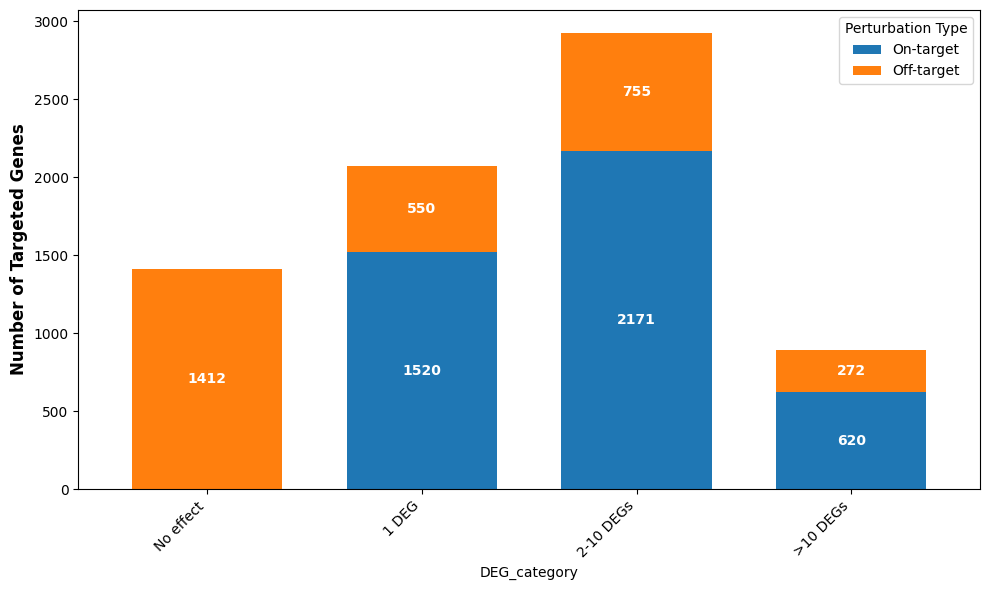

In [15]:
# Make summary plot
# Count DEGs per target gene (contrast)
deg_counts = deg_sig.groupby('KO').size().reset_index(name='n_DEGs')

# Identify on-target hits
on_target_genes = deg_sig[deg_sig['KO'] == deg_sig['gene_name']]['KO'].unique()

# Create categories for number of DEGs
def categorize_deg_count(n):
    if n == 0:
        return 'No effect'
    elif n == 1:
        return '1 DEG'
    elif n <= 10:
        return '2-10 DEGs'
    else:
        return '>10 DEGs'

deg_counts['DEG_category'] = deg_counts['n_DEGs'].apply(categorize_deg_count)
deg_counts['on_target'] = deg_counts['KO'].isin(on_target_genes)

# Count by category and on-target status
summary_counts = deg_counts.groupby(['DEG_category', 'on_target']).size().reset_index(name='count')
summary_counts['on_target_label'] = summary_counts['on_target'].map({True: 'On-target', False: 'Off-target'})

# For "No effect" add missing on-target row if not present
all_genes = deg_res.KO.unique()
no_effect_count = (~np.isin(all_genes, deg_counts.KO.unique())).sum()

# add these to summary_counts
summary_counts = pd.concat([summary_counts,
                            pd.DataFrame({'DEG_category': ['No effect'],
                                          'on_target': [False],
                                          'count': [no_effect_count],
                                          'on_target_label': ['Off-target']})],
                           ignore_index=True)


# Create the barplot
fig, ax = plt.subplots(figsize=(10, 6))

# Use seaborn for stacked barplot
pivot_data = summary_counts.pivot(index='DEG_category', columns='on_target_label', values='count').fillna(0)

# Reorder columns to have On-target first (bottom bar)
pivot_data = pivot_data[['On-target', 'Off-target']]

# Reorder rows to have 'No effect' first
category_order = ['No effect', '1 DEG', '2-10 DEGs', '>10 DEGs']
pivot_data = pivot_data.reindex(category_order)

# Get seaborn colors
seaborn_colors = sns.color_palette()

pivot_data.plot(kind='bar', stacked=True, ax=ax, 
                color=[seaborn_colors[0], seaborn_colors[1]],  # seaborn default colors
                width=0.7)

# Add numbers to each bar segment
for i, category in enumerate(pivot_data.index):
    # On-target (bottom)
    on_target_val = pivot_data.loc[category, 'On-target']
    if on_target_val > 0:
        ax.text(i, on_target_val / 2, f'{int(on_target_val)}', 
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
    # Off-target (top)
    off_target_val = pivot_data.loc[category, 'Off-target']
    if off_target_val > 0:
        ax.text(i, on_target_val + off_target_val / 2, f'{int(off_target_val)}', 
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')

#ax.set_xlabel('Number of Downstream Effects', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Targeted Genes', fontsize=12, fontweight='bold')
#ax.set_title('Target Genes by Downstream Effects and On-Target Status', fontsize=14, fontweight='bold')
ax.legend(title='Perturbation Type', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/g/stegle/schrod/code/TCell/plots/final/overview_barplot_deg_counts.pdf', bbox_inches='tight')
plt.show()

In [43]:
# Plot knockdown efficiency for individual datasets
def plot_knockdown_efficiency(df, dataset_name="Dataset", output_dir="/g/stegle/schrod/code/TCell/plots/final", on_target_genes=None):
    """
    Plot ordered knockdown efficiency for a single dataset
    - Sorted by control_mean (highest to lowest)
    - Control expression in blue
    - Perturbed expression colored by significance and direction
    """
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    # Set seaborn style and get color palette
    sns.set_style("white")
    colors = sns.color_palette()
    control_color = colors[0] # Blue
    
    # Color scheme based on significance
    if on_target_genes is not None:
        perturbed_nonsig_color = 'lightgray'
        perturbed_sig_down_color = colors[2]  # Green - significant downregulation
        perturbed_upregulated_color = colors[3]  # Red - upregulation
    else:
        perturbed_nonsig_color = 'gray'
        perturbed_sig_down_color = perturbed_nonsig_color
        perturbed_upregulated_color = colors[3]  # Red
    
    # Sort by control mean (ascending)
    df_sorted = df.sort_values('control_mean').reset_index(drop=True)
    
    # Determine colors for perturbed points
    perturbed_colors = []
    n_sig_knockdown = 0
    n_nonsig_knockdown = 0
    n_upregulated = 0
    
    for _, row in df_sorted.iterrows():
        if row['perturbed_mean'] > row['control_mean']:
            # Upregulation
            perturbed_colors.append(perturbed_upregulated_color)
            n_upregulated += 1
        elif on_target_genes is not None and row['gene'] in on_target_genes:
            # Significant knockdown
            perturbed_colors.append(perturbed_sig_down_color)
            n_sig_knockdown += 1
        else:
            # Non-significant knockdown
            perturbed_colors.append(perturbed_nonsig_color)
            n_nonsig_knockdown += 1
    
    median_fraction = df_sorted['fraction'].median()
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot perturbed expression with conditional coloring (plot first so control is on top)
    ax.scatter(range(len(df_sorted)), df_sorted['perturbed_mean'], 
               s=15, alpha=0.6, c=perturbed_colors, marker='.')
    
    # Plot control expression (on top, more visible)
    ax.scatter(range(len(df_sorted)), df_sorted['control_mean'], 
               s=25, alpha=0.7, color=control_color, marker='.', zorder=3)
    
    # Custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='.', color='w', markerfacecolor=control_color, markersize=12, label='Control'),
    ]
    
    if on_target_genes is not None:
        legend_elements.extend([
            Line2D([0], [0], marker='.', color='w', markerfacecolor=perturbed_upregulated_color, markersize=12, 
                   label=f'Upregulated: {n_upregulated} ({n_upregulated/len(df_sorted)*100:.1f}%)'),
            Line2D([0], [0], marker='.', color='w', markerfacecolor=perturbed_nonsig_color, markersize=12, 
                   label=f'Non-significant KD: {n_nonsig_knockdown} ({n_nonsig_knockdown/len(df_sorted)*100:.1f}%)'),
            Line2D([0], [0], marker='.', color='w', markerfacecolor=perturbed_sig_down_color, markersize=12, 
                   label=f'Significant KD: {n_sig_knockdown} ({n_sig_knockdown/len(df_sorted)*100:.1f}%)'),
        ])
    else:
        legend_elements.extend([
            Line2D([0], [0], marker='.', color='w', markerfacecolor=perturbed_upregulated_color, markersize=12, 
                   label=f'Upregulated: {n_upregulated} ({n_upregulated/len(df_sorted)*100:.1f}%)'),
            Line2D([0], [0], marker='.', color='w', markerfacecolor=perturbed_nonsig_color, markersize=12, 
                   label=f'Downregulated: {n_nonsig_knockdown} ({n_nonsig_knockdown/len(df_sorted)*100:.1f}%)'),
        ])
    
    ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)
    
    #ax.set_title(f"{dataset_name}: Control vs Perturbed expression | Median fraction: {median_fraction:.2f}",  fontsize=14, fontweight='bold')
    ax.set_xlabel("Perturbed genes (sorted by mean expression of control)", fontsize=12)
    ax.set_ylabel("Perturbed gene mean expression \n (log normalized)", fontsize=12)
    
    plt.tight_layout()
    
    # Save plot
    output_path = os.path.join(output_dir, f"{dataset_name}_knockdown_efficiency.pdf")
    plt.savefig(output_path, bbox_inches='tight')
    plt.show()
    logger.info(f"Saved {dataset_name} knockdown efficiency plot to {output_path}")


In [41]:
def plot_knockdown_efficiency_by_deg_category(df, deg_counts, dataset_name="Dataset", output_dir="/g/stegle/schrod/code/TCell/plots/final"):
    """
    Plot ordered knockdown efficiency for a single dataset
    - Sorted by control_mean (highest to lowest)
    - Control expression in blue
    - Perturbed expression colored by DEG category
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with columns: gene, control_mean, perturbed_mean, fraction
    deg_counts : pd.DataFrame
        DataFrame with columns: KO, n_DEGs, DEG_category
    dataset_name : str
        Name of the dataset for plot title and filename
    output_dir : str
        Directory to save the plot
    """
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    # Set seaborn style and get color palette
    sns.set_style("white")
    colors = sns.color_palette()
    control_color = colors[0]  # Blue
    
    # Define colors for each DEG category
    category_colors = {
        'No effect': 'lightgray',
        '1 DEG': colors[1],      # Orange
        '2-10 DEGs': colors[2],  # Green
        '>10 DEGs': colors[3]    # Red
    }
    
    # Merge with deg_counts to get DEG_category
    df_merged = df.merge(deg_counts[['KO', 'DEG_category']], left_on='gene', right_on='KO', how='left')
    df_merged['DEG_category'] = df_merged['DEG_category'].fillna('No effect')
    
    # Sort by control mean (ascending)
    df_sorted = df_merged.sort_values('control_mean').reset_index(drop=True)
    
    # Determine colors for perturbed points and count categories
    perturbed_colors = []
    category_counts = {'No effect': 0, '1 DEG': 0, '2-10 DEGs': 0, '>10 DEGs': 0}
    
    for _, row in df_sorted.iterrows():
        category = row['DEG_category']
        perturbed_colors.append(category_colors[category])
        category_counts[category] += 1
    
    median_fraction = df_sorted['fraction'].median()
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot perturbed expression with category-based coloring (plot first so control is on top)
    ax.scatter(range(len(df_sorted)), df_sorted['perturbed_mean'], 
               s=15, alpha=0.6, c=perturbed_colors, marker='.')
    
    # Plot control expression (on top, more visible)
    ax.scatter(range(len(df_sorted)), df_sorted['control_mean'], 
               s=25, alpha=0.7, color=control_color, marker='.', zorder=3)
    
    # Custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='.', color='w', markerfacecolor=control_color, markersize=12, label='Control'),
    ]
    
    # Add legend entries for each category in order
    for category in ['No effect', '1 DEG', '2-10 DEGs', '>10 DEGs']:
        count = category_counts[category]
        pct = count / len(df_sorted) * 100
        legend_elements.append(
            Line2D([0], [0], marker='.', color='w', markerfacecolor=category_colors[category], 
                   markersize=12, label=f'{category}: {count} ({pct:.1f}%)')
        )
    
    ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)
    
    ax.set_xlabel("Perturbed genes (sorted by mean expression of control)", fontsize=12)
    ax.set_ylabel("Perturbed gene mean expression \n (log normalized)", fontsize=12)
    
    plt.tight_layout()
    
    # Save plot
    output_path = os.path.join(output_dir, f"{dataset_name}_knockdown_efficiency_by_deg.pdf")
    plt.savefig(output_path, bbox_inches='tight')
    plt.show()
    logger.info(f"Saved {dataset_name} knockdown efficiency plot (by DEG category) to {output_path}")

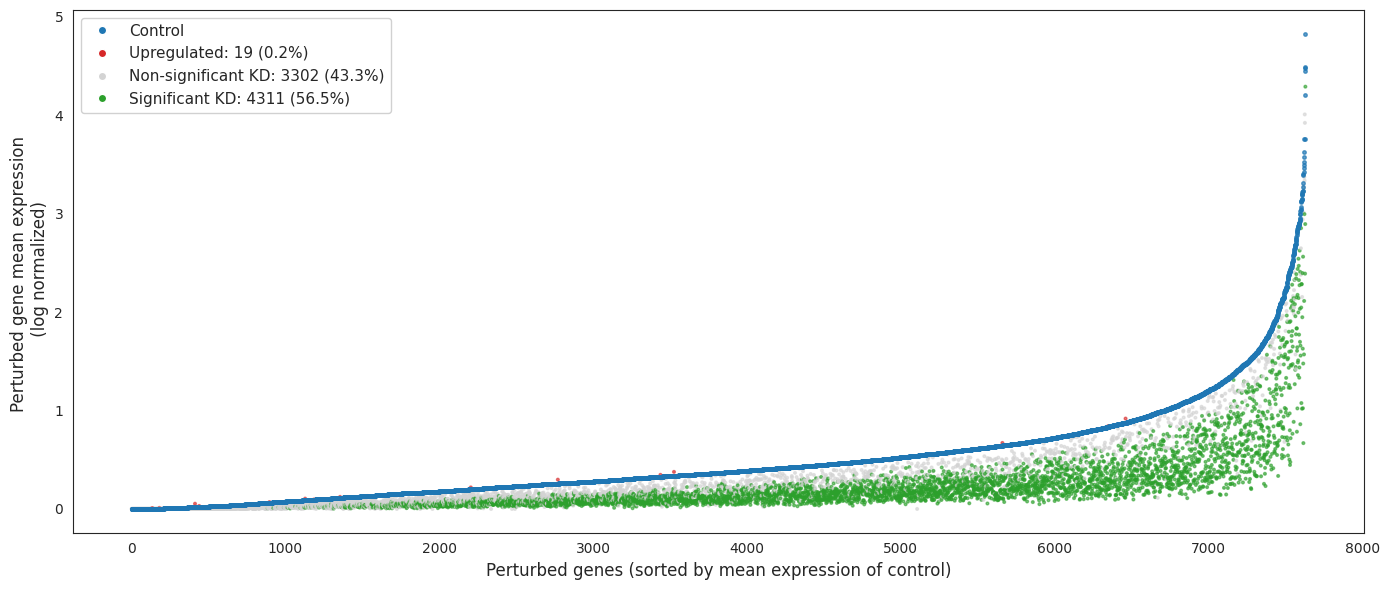

[2026-02-18 17:41:34,444] INFO:__main__: Saved OTAR knockdown efficiency plot to /g/stegle/schrod/code/TCell/plots/final/OTAR_knockdown_efficiency.pdf


In [46]:
# Generate plots for each dataset
plot_knockdown_efficiency(df_otar, "OTAR", on_target_genes=on_target)

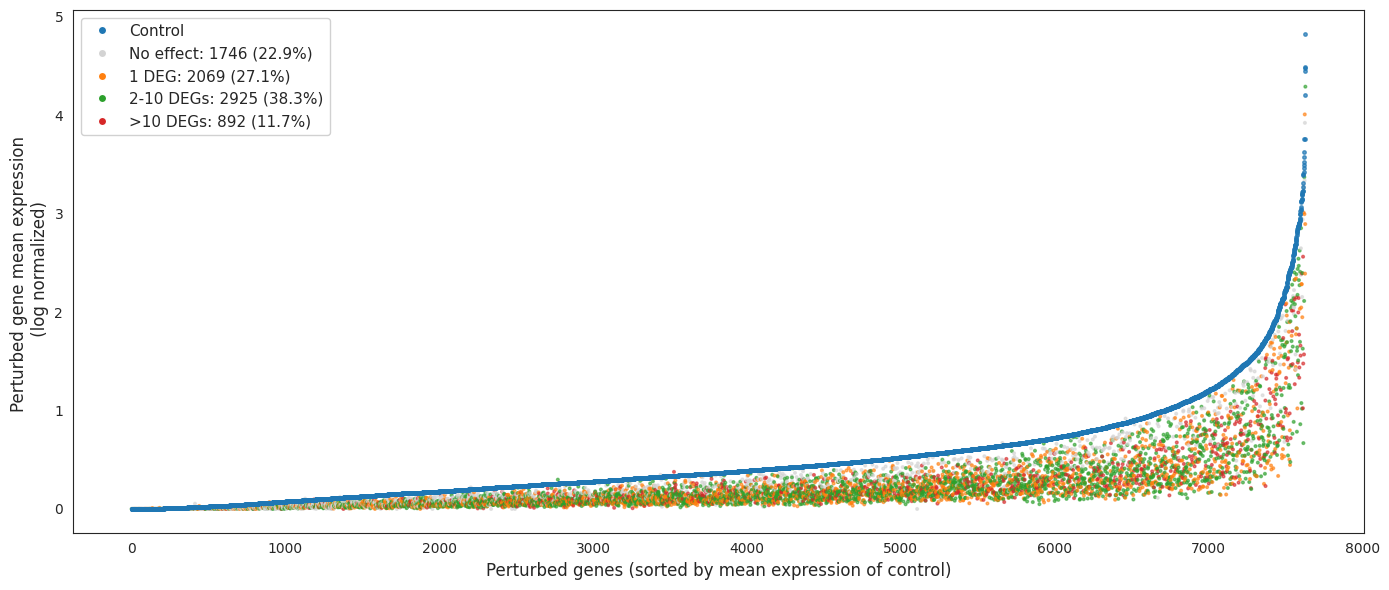

[2026-02-16 14:30:10,991] INFO:__main__: Saved OTAR knockdown efficiency plot (by DEG category) to /g/stegle/schrod/code/TCell/plots/final/OTAR_knockdown_efficiency_by_deg.pdf


In [20]:
# Generate DEG category plots for OTAR dataset
plot_knockdown_efficiency_by_deg_category(df_otar, deg_counts, "OTAR")

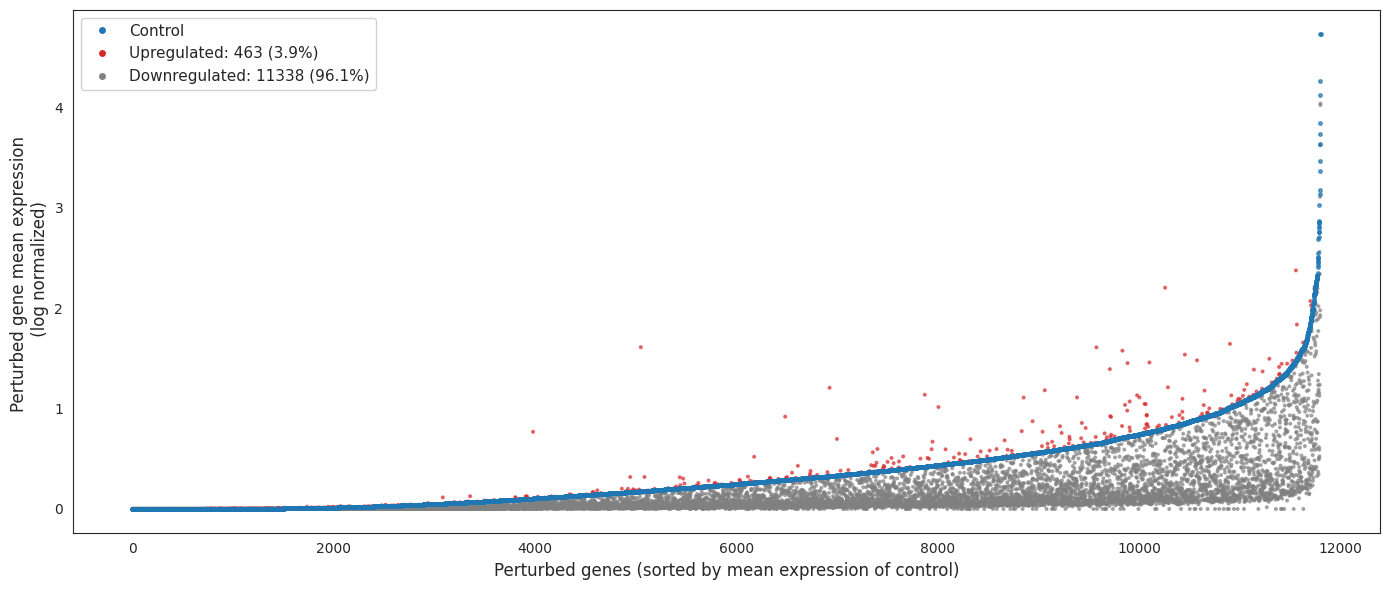

[2026-02-16 14:27:18,923] INFO:__main__: Saved Marson knockdown efficiency plot to /g/stegle/schrod/code/TCell/plots/final/Marson_knockdown_efficiency.pdf


In [18]:
plot_knockdown_efficiency(df_marson, "Marson")


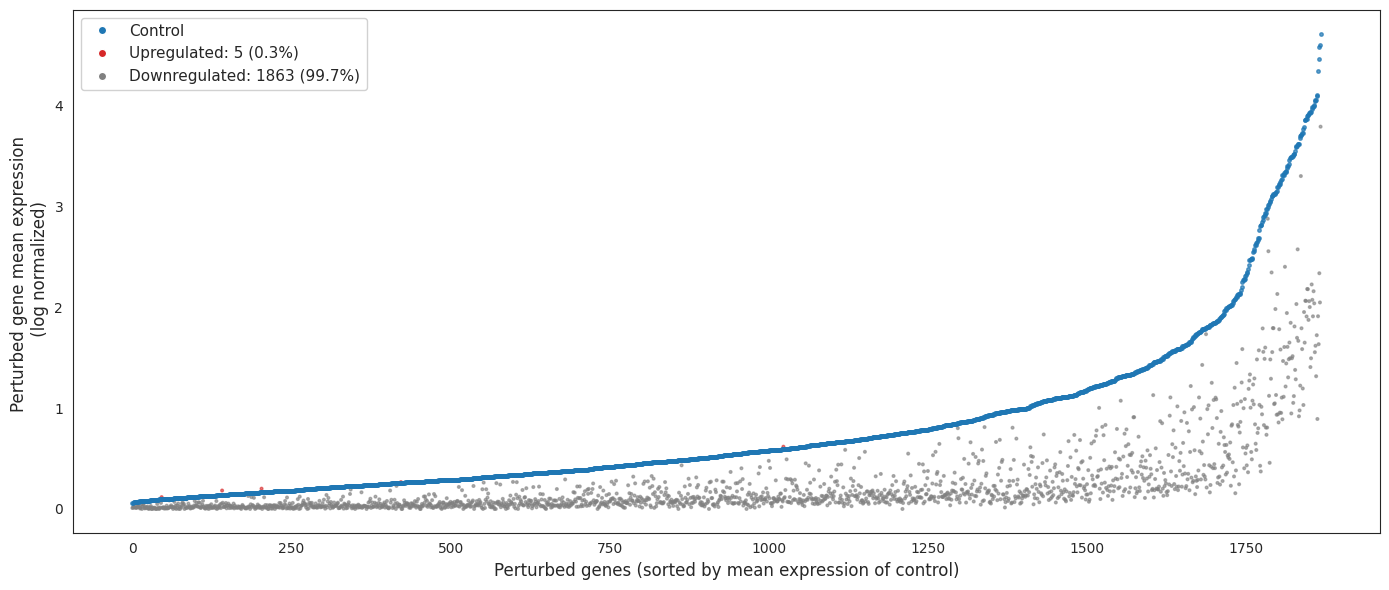

[2026-02-06 12:38:47,134] INFO:__main__: Saved K562 knockdown efficiency plot to /g/stegle/schrod/code/TCell/plots/final/K562_knockdown_efficiency.pdf


In [49]:
plot_knockdown_efficiency(df_K562, "K562")

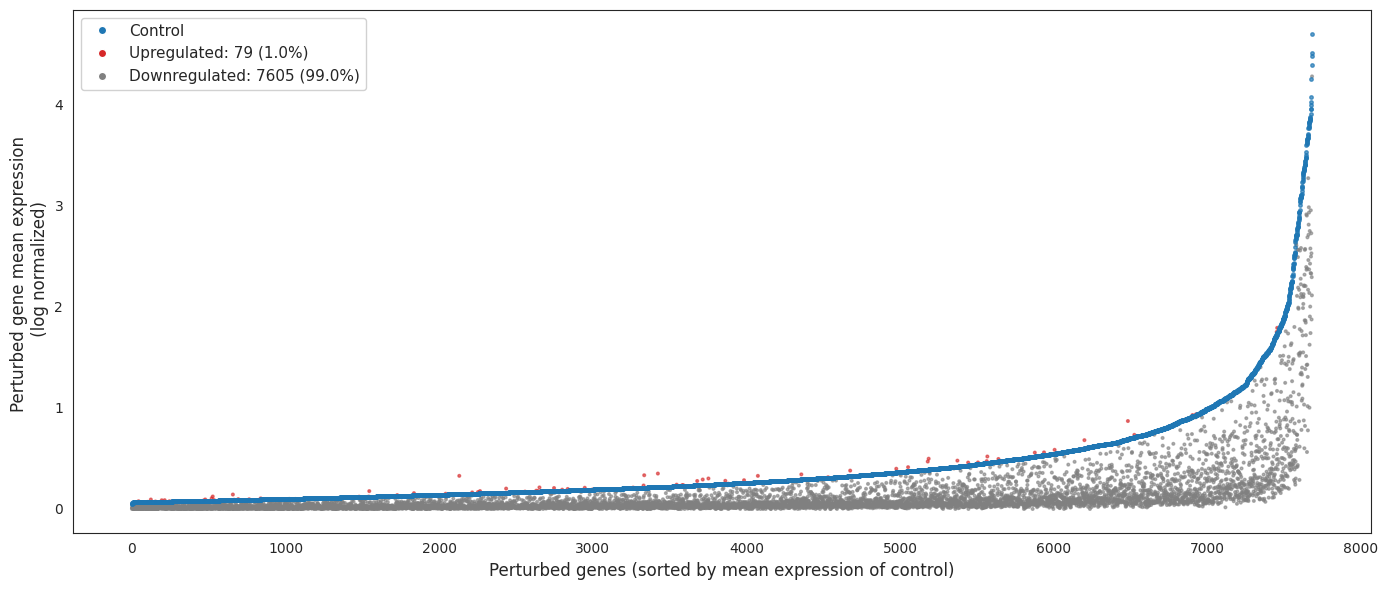

[2026-02-06 12:38:48,451] INFO:__main__: Saved K562_GWPS knockdown efficiency plot to /g/stegle/schrod/code/TCell/plots/final/K562_GWPS_knockdown_efficiency.pdf


In [50]:
plot_knockdown_efficiency(df_K562_gwps, "K562_GWPS")

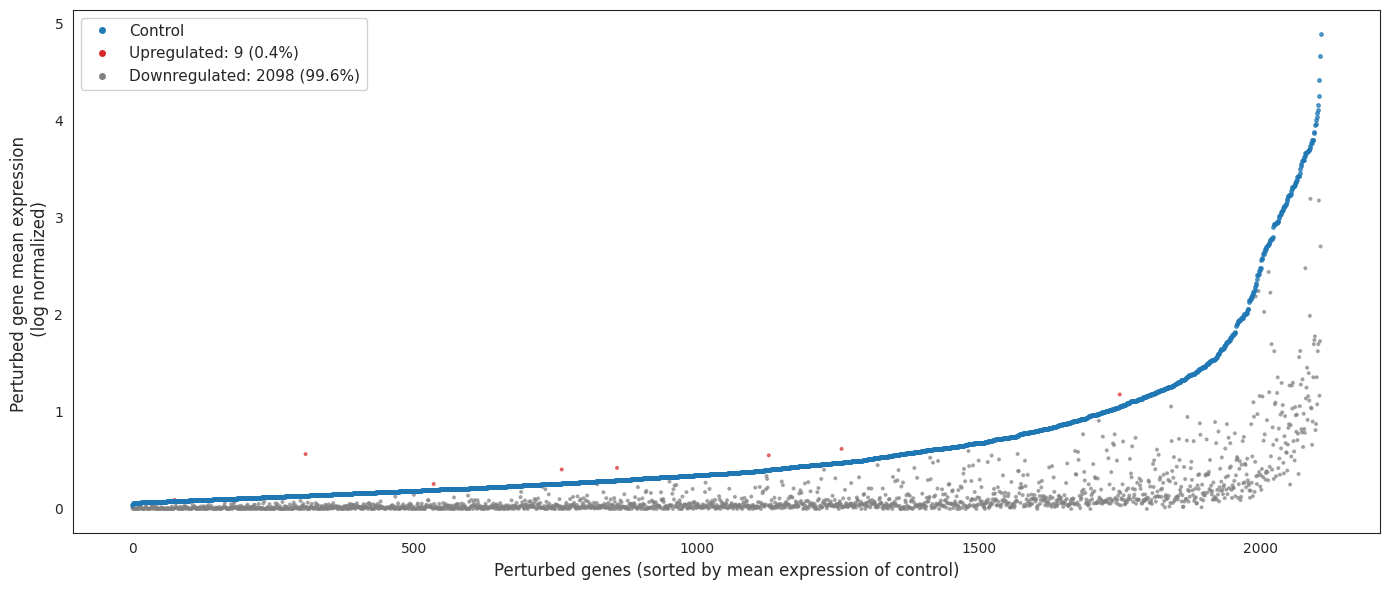

[2026-02-06 12:38:49,024] INFO:__main__: Saved RPE1 knockdown efficiency plot to /g/stegle/schrod/code/TCell/plots/final/RPE1_knockdown_efficiency.pdf


In [51]:
plot_knockdown_efficiency(df_rpe1, "RPE1")

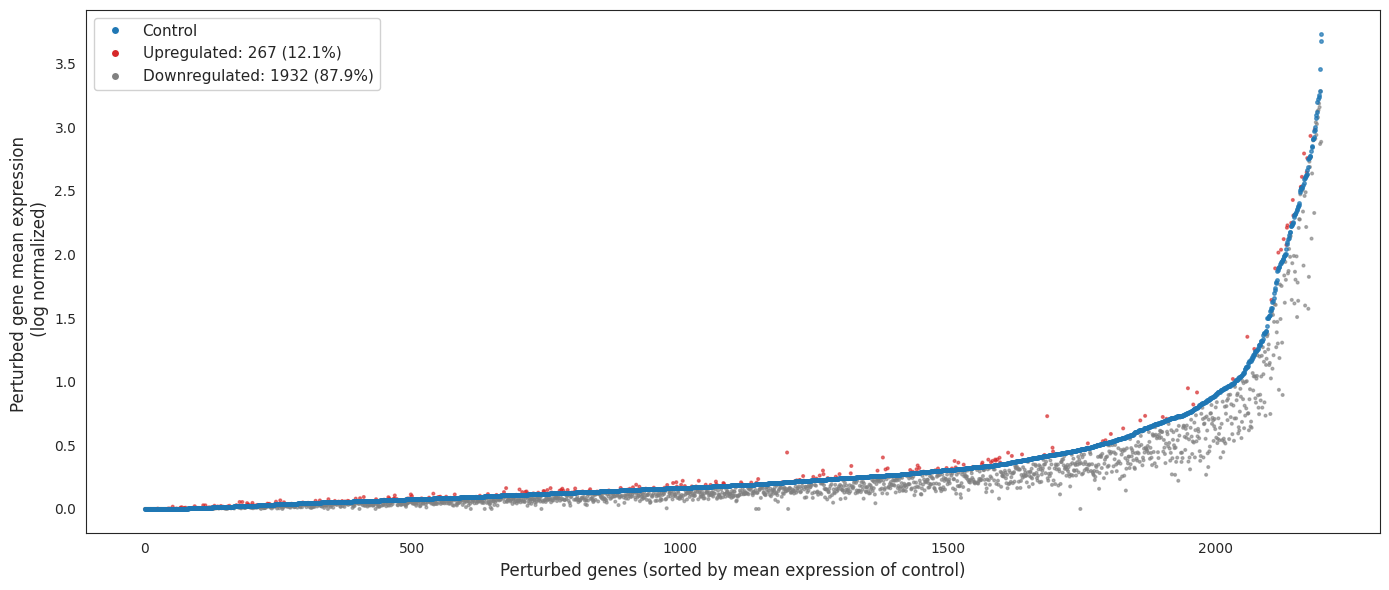

[2026-02-06 12:38:49,805] INFO:__main__: Saved iPSC_Fitness knockdown efficiency plot to /g/stegle/schrod/code/TCell/plots/final/iPSC_Fitness_knockdown_efficiency.pdf


In [52]:
plot_knockdown_efficiency(df_fitness, "iPSC_Fitness")

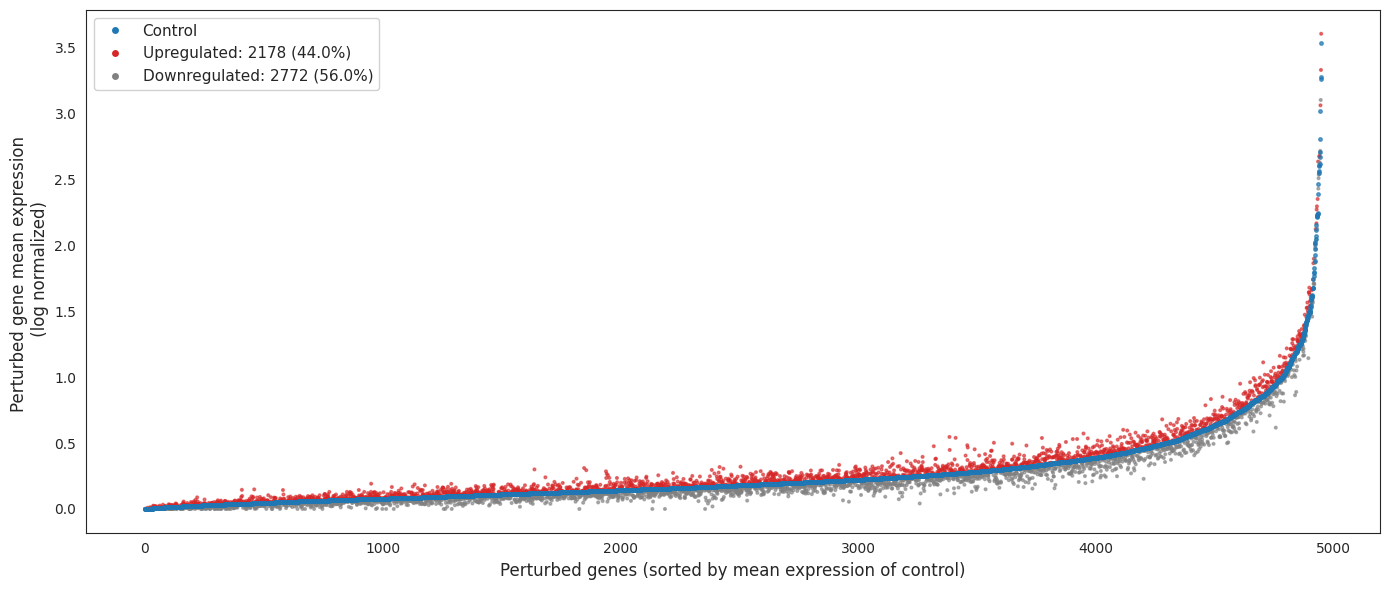

[2026-02-06 12:38:50,833] INFO:__main__: Saved iPSC_NonFitness knockdown efficiency plot to /g/stegle/schrod/code/TCell/plots/final/iPSC_NonFitness_knockdown_efficiency.pdf


In [53]:
plot_knockdown_efficiency(df_nonfitness, "iPSC_NonFitness")